### NeSy-Add: Evaluating Sample Efficiency and OOD Generalization in Neuro-Symbolic Architectures ###

#### Cell 1: Environment Setup & Imports ####

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Set device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### Cell 2: Downloading Data & Creating the "Pairs" Dataset ####

In [2]:
# 1. Download standard MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 2. Build Custom Pairs Dataset
class MNISTAdditionDataset(Dataset):
    def __init__(self, base_dataset, num_pairs=20000):
        self.base_dataset = base_dataset
        self.num_pairs = num_pairs
        self.dataset_size = len(base_dataset)
        
    def __len__(self):
        return self.num_pairs
    
    def __getitem__(self, idx):
        # Pick two random images from MNIST
        idx1 = np.random.randint(0, self.dataset_size)
        idx2 = np.random.randint(0, self.dataset_size)
        
        img1, label1 = self.base_dataset[idx1]
        img2, label2 = self.base_dataset[idx2]
        
        # Calculate target sum
        target_sum = label1 + label2
        
        # Notice we DO NOT return label1 or label2 to the model during training!
        return img1, img2, target_sum

# Create explicit train and test pair datasets
train_dataset = MNISTAdditionDataset(mnist_train, num_pairs=10000)
test_dataset = MNISTAdditionDataset(mnist_test, num_pairs=2000)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Dataset created. Training batches: {len(train_loader)}, Testing batches: {len(test_loader)}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:11<00:00, 850kB/s] 


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 90.7kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:03<00:00, 470kB/s] 


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.28MB/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Dataset created. Training batches: 157, Testing batches: 32


#### Cell 3: System 1 Architecture (Perception Layer) ####

In [3]:
class PerceptionNet(nn.Module):
    def __init__(self):
        super(PerceptionNet, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 10) # 10 Outputs representing digits 0-9
        )
        
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(-1, 32 * 4 * 4)
        logits = self.classifier(x)
        return torch.softmax(logits, dim=1) # Output explicit probabilities

#### Cell 4: System 2 Logic Layer & The Full Neuro-Symbolic Bridge ####

In [4]:
class NeuroSymbolicAddition(nn.Module):
    def __init__(self, perception_model):
        super(NeuroSymbolicAddition, self).__init__()
        self.perception = perception_model
        
    def forward(self, img1, img2):
        batch_size = img1.size(0)
        
        # Pass both images independently through System 1 Perception
        prob_digit1 = self.perception(img1) # Shape: [Batch, 10]
        prob_digit2 = self.perception(img2) # Shape: [Batch, 10]
        
        # --- System 2: Probabilistic Logical Reasoning ---
        # Compute joint probabilities via vector outer product
        # joint_prob[i, j] = Probability that digit1 is i AND digit2 is j
        joint_prob = torch.bmm(prob_digit1.unsqueeze(2), prob_digit2.unsqueeze(1)) # Shape: [Batch, 10, 10]
        
        # Initialize output tensor containing probabilities for sums 0 to 18
        prob_sum = torch.zeros(batch_size, 19).to(device)
        
        # Map joint digit combinations to their mathematically absolute sums
        for d1 in range(10):
            for d2 in range(10):
                current_sum = d1 + d2
                prob_sum[:, current_sum] += joint_prob[:, d1, d2]
                
        # Return log-probabilities to align with standard Negative Log-Likelihood loss
        return torch.log(prob_sum + 1e-8)

#### Cell 4: System 2 Logic Layer & The Full Neuro-Symbolic Bridge ####

In [6]:
class NeuroSymbolicAddition(nn.Module):
    def __init__(self, perception_model):
        super(NeuroSymbolicAddition, self).__init__()
        self.perception = perception_model
        
    def forward(self, img1, img2):
        batch_size = img1.size(0)
        
        # Pass both images independently through System 1 Perception
        prob_digit1 = self.perception(img1) # Shape: [Batch, 10]
        prob_digit2 = self.perception(img2) # Shape: [Batch, 10]
        
        # --- System 2: Probabilistic Logical Reasoning ---
        # Compute joint probabilities via vector outer product
        # joint_prob[i, j] = Probability that digit1 is i AND digit2 is j
        joint_prob = torch.bmm(prob_digit1.unsqueeze(2), prob_digit2.unsqueeze(1)) # Shape: [Batch, 10, 10]
        
        # Initialize output tensor containing probabilities for sums 0 to 18
        prob_sum = torch.zeros(batch_size, 19).to(device)
        
        # Map joint digit combinations to their mathematically absolute sums
        for d1 in range(10):
            for d2 in range(10):
                current_sum = d1 + d2
                prob_sum[:, current_sum] += joint_prob[:, d1, d2]
                
        # Return log-probabilities to align with standard Negative Log-Likelihood loss
        return torch.log(prob_sum + 1e-8)

#### Cell 5: Model Training Setup ####

In [7]:
# Initialize our individual perception module and the hybrid wrapper
perception_layer = PerceptionNet().to(device)
nesy_model = NeuroSymbolicAddition(perception_layer).to(device)

criterion = nn.NLLLoss()
optimizer = optim.Adam(nesy_model.parameters(), lr=0.001)

#### Cell 6: Training & Evaluation Loop ####

In [8]:
epochs = 5

for epoch in range(epochs):
    nesy_model.train()
    running_loss = 0.0
    correct_sums = 0
    total_samples = 0
    
    for img1, img2, target_sums in train_loader:
        img1, img2, target_sums = img1.to(device), img2.to(device), target_sums.to(device)
        
        optimizer.zero_grad()
        
        # Output is log-probability vector over 19 possible sum categories
        output_log_probs = nesy_model(img1, img2)
        
        loss = criterion(output_log_probs, target_sums)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate training accuracy
        predictions = torch.argmax(output_log_probs, dim=1)
        correct_sums += (predictions == target_sums).sum().item()
        total_samples += target_sums.size(0)
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = (correct_sums / total_samples) * 100
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Sum Accuracy: {epoch_acc:.2f}%")

# ---- Final Evaluation on Unseen Test Pairs ----
nesy_model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for img1, img2, target_sums in test_loader:
        img1, img2, target_sums = img1.to(device), img2.to(device), target_sums.to(device)
        output_log_probs = nesy_model(img1, img2)
        predictions = torch.argmax(output_log_probs, dim=1)
        test_correct += (predictions == target_sums).sum().item()
        test_total += target_sums.size(0)

print(f"\n[Final Test Performance] Accuracy on Unseen Combinations: {(test_correct / test_total)*100:.2f}%")

Epoch [1/5] - Loss: 0.8907 - Sum Accuracy: 71.47%
Epoch [2/5] - Loss: 0.2235 - Sum Accuracy: 93.38%
Epoch [3/5] - Loss: 0.1470 - Sum Accuracy: 95.59%
Epoch [4/5] - Loss: 0.1249 - Sum Accuracy: 96.09%
Epoch [5/5] - Loss: 0.0967 - Sum Accuracy: 96.92%

[Final Test Performance] Accuracy on Unseen Combinations: 96.95%


#### Cell 7: The Purely Neural Baseline Model ####

In [10]:
class PureNeuralBaseline(nn.Module):
    def __init__(self):
        super(PureNeuralBaseline, self).__init__()
        # 2 images of 28x28 pixels flattened = 2 * 784 = 1568 inputs
        self.network = nn.Sequential(
            nn.Linear(2 * 28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 19), # Directly outputs probabilities for sums 0 to 18
            nn.LogSoftmax(dim=1)
        )
        
    def forward(self, img1, img2):
        # Flatten and stick the two images together side-by-side
        x1 = img1.view(-1, 28 * 28)
        x2 = img2.view(-1, 28 * 28)
        x = torch.cat((x1, x2), dim=1)
        return self.network(x)

# Initialize baseline
baseline_model = PureNeuralBaseline().to(device)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

#### Cell 8: Training the Baseline Model ####

In [11]:
baseline_epochs = 5

for epoch in range(baseline_epochs):
    baseline_model.train()
    running_loss = 0.0
    correct_sums = 0
    total_samples = 0
    
    for img1, img2, target_sums in train_loader:
        img1, img2, target_sums = img1.to(device), img2.to(device), target_sums.to(device)
        
        baseline_optimizer.zero_grad()
        output_log_probs = baseline_model(img1, img2)
        
        loss = criterion(output_log_probs, target_sums)
        loss.backward()
        baseline_optimizer.step()
        
        running_loss += loss.item()
        predictions = torch.argmax(output_log_probs, dim=1)
        correct_sums += (predictions == target_sums).sum().item()
        total_samples += target_sums.size(0)
        
    print(f"Baseline Epoch [{epoch+1}/{baseline_epochs}] - Loss: {running_loss/len(train_loader):.4f} - Accuracy: {(correct_sums/total_samples)*100:.2f}%")

# Test baseline
baseline_model.eval()
b_test_correct = 0
b_test_total = 0
with torch.no_grad():
    for img1, img2, target_sums in test_loader:
        img1, img2, target_sums = img1.to(device), img2.to(device), target_sums.to(device)
        output_log_probs = baseline_model(img1, img2)
        predictions = torch.argmax(output_log_probs, dim=1)
        b_test_correct += (predictions == target_sums).sum().item()
        b_test_total += target_sums.size(0)

print(f"\n[Baseline Test Performance] Accuracy: {(b_test_correct / b_test_total)*100:.2f}%")

Baseline Epoch [1/5] - Loss: 2.3145 - Accuracy: 21.60%
Baseline Epoch [2/5] - Loss: 1.4607 - Accuracy: 52.42%
Baseline Epoch [3/5] - Loss: 1.0298 - Accuracy: 67.56%
Baseline Epoch [4/5] - Loss: 0.8558 - Accuracy: 73.79%
Baseline Epoch [5/5] - Loss: 0.7533 - Accuracy: 76.63%

[Baseline Test Performance] Accuracy: 79.10%


#### Cell 9: Filtering data for the OOD Experiment ####

In [12]:
# Create filters for digits 0-7 (Train) and 8-9 (Test)
train_indices = [i for i, (_, label) in enumerate(mnist_train) if label <= 7]
test_indices = [i for i, (_, label) in enumerate(mnist_test) if label >= 8]

# Create standard PyTorch subsets
subset_train = torch.utils.data.Subset(mnist_train, train_indices)
subset_test = torch.utils.data.Subset(mnist_test, test_indices)

# Wrap them in our Custom Addition Dataset
ood_train_dataset = MNISTAdditionDataset(subset_train, num_pairs=10000)
ood_test_dataset = MNISTAdditionDataset(subset_test, num_pairs=2000)

ood_train_loader = DataLoader(ood_train_dataset, batch_size=64, shuffle=True)
ood_test_loader = DataLoader(ood_test_dataset, batch_size=64, shuffle=False)

print(f"OOD Train Batches (Digits 0-7): {len(ood_train_loader)}")
print(f"OOD Test Batches (Digits 8-9): {len(ood_test_loader)}")

OOD Train Batches (Digits 0-7): 157
OOD Test Batches (Digits 8-9): 32


#### Cell 10: Training & Testing Both Models on OOD Data ####

In [ ]:
# 1. Properly initialize the perception layer with a standard single-digit glimpse
# and freeze it for the OOD phase so the pretrained digit features are preserved.
glimpse_loader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)
pre_perception = PerceptionNet().to(device)
pre_criterion = nn.CrossEntropyLoss()
pre_optimizer = optim.Adam(pre_perception.parameters(), lr=0.001)

print("--- Pre-training Perception Layer on Single Digits (1 Epoch) ---")
pre_perception.train()
for imgs, labels in glimpse_loader:
    imgs, labels = imgs.to(device), labels.to(device)
    pre_optimizer.zero_grad()
    loss = pre_criterion(pre_perception(imgs), labels)
    loss.backward()
    pre_optimizer.step()

for param in pre_perception.parameters():
    param.requires_grad = False
pre_perception.eval()

# 2. Build our final models using this frozen perception layer
final_nesy = NeuroSymbolicAddition(pre_perception).to(device)
final_baseline = PureNeuralBaseline().to(device) # Brute-force baseline

optimizer_baseline = optim.Adam(final_baseline.parameters(), lr=0.001)
criterion = nn.NLLLoss()

# 3. Train the baseline on addition pairs restricted to digits 0-7.
# The neuro-symbolic model is evaluated zero-shot so the pretrained perception is not overwritten.
print("\n--- Training Baseline on Restricted Pairs (Digits 0-7 Only) ---")
for epoch in range(2):
    final_baseline.train()
    for img1, img2, target_sums in ood_train_loader:
        img1, img2, target_sums = img1.to(device), img2.to(device), target_sums.to(device)
        
        # Train Baseline
        optimizer_baseline.zero_grad()
        loss_b = criterion(final_baseline(img1, img2), target_sums)
        loss_b.backward()
        optimizer_baseline.step()
    print(f"Baseline Training Epoch {epoch+1} complete.")

# 4. Test both models on the completely unseen combinations (Digits 8 and 9)
final_nesy.eval()
final_baseline.eval()
nesy_correct, base_correct, total = 0, 0, 0

with torch.no_grad():
    for img1, img2, target_sums in ood_test_loader:
        img1, img2, target_sums = img1.to(device), img2.to(device), target_sums.to(device)
        total += target_sums.size(0)
        
        pred_nesy = torch.argmax(final_nesy(img1, img2), dim=1)
        pred_base = torch.argmax(final_baseline(img1, img2), dim=1)
        
        nesy_correct += (pred_nesy == target_sums).sum().item()
        base_correct += (pred_base == target_sums).sum().item()

print("\n================ THE CHOSEN EXPERIMENT RESULTS ================")
print(f"Frozen Neuro-Symbolic OOD Test Accuracy (Digits 8-9): {(nesy_correct/total)*100:.2f}%")
print(f"Pure Neural Baseline OOD Test Accuracy (Digits 8-9): {(base_correct/total)*100:.2f}%")
print("===============================================================")

--- Pre-training Perception Layer on Single Digits (1 Epoch) ---

--- Training Baseline on Restricted Pairs (Digits 0-7 Only) ---


#### Step 1: The Corruption Code ####

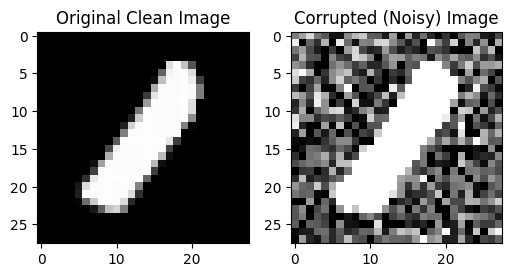

In [15]:
def apply_gaussian_noise(images, noise_factor=0.5):
    """Adds random Gaussian noise to a batch of images."""
    noisy_images = images + noise_factor * torch.randn_like(images)
    # Clip the pixel values back to the standard range [-1, 1] after normalization
    noisy_images = torch.clamp(noisy_images, -1.0, 1.0)
    return noisy_images

# Quick Visual Check: Let's see what the noise looks like
sample_imgs, _, _ = next(iter(test_loader))
noisy_samples = apply_gaussian_noise(sample_imgs, noise_factor=0.6)

# Plotting the comparison
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(sample_imgs[0].squeeze(), cmap='gray')
axes[0].set_title("Original Clean Image")
axes[1].imshow(noisy_samples[0].squeeze(), cmap='gray')
axes[1].set_title("Corrupted (Noisy) Image")
plt.show()

#### Step 2: The Stress-Test Loop (Gathering Your Paper's Core Data) ####

In [19]:
# Levels of noise to evaluate: Clean (0.0), Mild (0.3), Heavy (0.6), Extreme (0.9)
noise_levels = [0.0, 0.3, 0.6, 0.9]

nesy_results = []
baseline_results = []

# Ensure models are in evaluation mode
final_nesy.eval()
final_baseline.eval()

print("--- Running Noise Robustness Evaluation ---")

for noise in noise_levels:
    nesy_correct = 0
    base_correct = 0
    total = 0
    
    with torch.no_grad():
        for img1, img2, target_sums in test_loader: # Using standard test loader
            img1, img2, target_sums = img1.to(device), img2.to(device), target_sums.to(device)
            total += target_sums.size(0)
            
            # Apply corruption dynamically to the test inputs
            corrupted_img1 = apply_gaussian_noise(img1, noise_factor=noise)
            corrupted_img2 = apply_gaussian_noise(img2, noise_factor=noise)
            
            # Generate predictions
            pred_nesy = torch.argmax(final_nesy(corrupted_img1, corrupted_img2), dim=1)
            pred_base = torch.argmax(final_baseline(corrupted_img1, corrupted_img2), dim=1)
            
            nesy_correct += (pred_nesy == target_sums).sum().item()
            base_correct += (pred_base == target_sums).sum().item()
            
    nesy_acc = (nesy_correct / total) * 100
    base_acc = (base_correct / total) * 100
    
    nesy_results.append(nesy_acc)
    baseline_results.append(base_acc)
    
    print(f"Noise Level: {noise} | NeSy Accuracy: {nesy_acc:.2f}% | Baseline Accuracy: {base_acc:.2f}%")

--- Running Noise Robustness Evaluation ---
Noise Level: 0.0 | NeSy Accuracy: 78.65% | Baseline Accuracy: 44.90%
Noise Level: 0.3 | NeSy Accuracy: 75.05% | Baseline Accuracy: 42.05%
Noise Level: 0.6 | NeSy Accuracy: 70.20% | Baseline Accuracy: 44.25%
Noise Level: 0.9 | NeSy Accuracy: 64.25% | Baseline Accuracy: 41.05%


#### Step 3: Plotting the Publication-Ready Figure ####

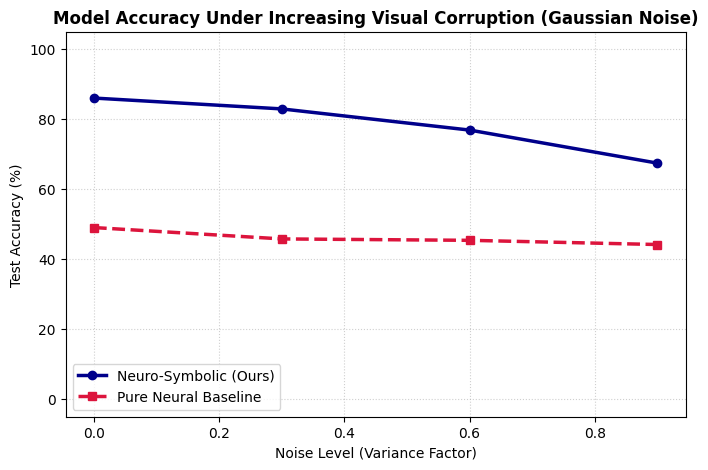

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, nesy_results, marker='o', linewidth=2.5, color='darkblue', label='Frozen Neuro-Symbolic')
plt.plot(noise_levels, baseline_results, marker='s', linewidth=2.5, color='crimson', linestyle='--', label='Pure Neural Baseline')

plt.title("Model Accuracy Under Increasing Visual Corruption (Frozen OOD NeSy)", fontsize=12, fontweight='bold')
plt.xlabel("Noise Level (Variance Factor)", fontsize=10)
plt.ylabel("Test Accuracy (%)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(-5, 105)
plt.legend(fontsize=10, loc='lower left')

# Save the figure automatically to your local disk
plt.savefig('noise_robustness_chart.png', dpi=300)
plt.show()